# ARIMA + XGBoost — Epoch-Based Training & Pickle Export
**Use for:** SMOOTH or ERRATIC demand (ADI < 1.32)

## What this notebook does
1. Loads and classifies the monthly sales dataset
2. Runs **epoch-based walk-forward validation** — each epoch shifts the training window
   one step forward, simulates re-training, and records metrics
3. After all epochs, trains the **final model** on the complete dataset
4. **Saves every trained artefact to pickle** so the model can be reloaded without retraining
5. Demonstrates **loading from pickle** and running inference

## Epoch Design
Walk-forward validation uses an expanding window:
- **Epoch 1:** train on months 1–N₀, evaluate on months N₀+1 … N₀+H
- **Epoch 2:** train on months 1–N₀+1, evaluate on months N₀+2 … N₀+H+1
- … and so on for `N_EPOCHS` epochs
- This mirrors real-world retraining as new sales data arrives each month

```
│← train window (grows) →│← eval window (H months) →│
│███████████████████████│░░░░░░░░░░░░░░░░░░░░░░░░░░│  epoch 1
│████████████████████████│░░░░░░░░░░░░░░░░░░░░░░░░░░│  epoch 2
│█████████████████████████│░░░░░░░░░░░░░░░░░░░░░░░░░│  epoch 3
```


## 1. Imports & Style

In [1]:
import warnings, pickle, os, time, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm, probplot

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.35,'grid.linestyle':'--',
    'font.size':11,'axes.titlesize':13,'axes.titleweight':'bold',
    'axes.spines.top':False,'axes.spines.right':False
})
ORANGE,PURPLE,BLUE,GREEN,GRAY = '#FF6B00','#8b5cf6','#3b82f6','#10b981','#94a3b8'
print('✅  Libraries loaded')

✅  Libraries loaded


## 2. Configuration

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
CSV_PATH    = 'sales_2020_2024_5yr.csv'  # <-- update if needed
PICKLE_DIR  = Path('arima_xgb_models')   # folder where .pkl files are saved
PICKLE_DIR.mkdir(exist_ok=True)

# ── ARIMA candidate orders (mirrors arima_xgb_model.py) ──────────────────────
ARIMA_ORDERS_INITIAL  = [(1,1,1),(2,1,1),(1,1,2),(2,1,2),(0,1,1),(1,0,0)]
ARIMA_ORDERS_EXTENDED = [(3,1,1),(3,1,2),(2,1,3),(1,2,1),(2,2,1),(0,2,1),(3,0,1),(1,0,1)]
ALL_ARIMA_ORDERS      = ARIMA_ORDERS_INITIAL + ARIMA_ORDERS_EXTENDED

# ── XGBoost hyperparameters ───────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)

# ── Feature engineering ───────────────────────────────────────────────────────
LAG_FEATURES    = [1, 2, 3, 6, 12]
ROLLING_WINDOWS = [3, 6]

# ── Epoch / walk-forward config ───────────────────────────────────────────────
MIN_TRAIN_MONTHS = 24   # minimum months needed before first epoch starts
EVAL_HORIZON     = 3    # months evaluated per epoch
N_EPOCHS         = 12   # how many walk-forward steps to run
                        # each epoch shifts the window 1 month forward

# ── Final model config ────────────────────────────────────────────────────────
FINAL_TEST_SIZE  = 6    # months withheld for final hold-out evaluation
CI_ALPHA         = 0.05 # 95% confidence interval
POOR_MAPE_THR    = 25.0 # % — would trigger auto-retrain in production

print(f'Pickle directory : {PICKLE_DIR.resolve()}')
print(f'Epochs           : {N_EPOCHS}')
print(f'Min train window : {MIN_TRAIN_MONTHS} months')
print(f'Eval horizon     : {EVAL_HORIZON} months per epoch')
print(f'Final test size  : {FINAL_TEST_SIZE} months')

Pickle directory : C:\Users\Joem Inciong\automotive-spare-parts-dss-thesis\arima_xgb_models
Epochs           : 12
Min train window : 24 months
Eval horizon     : 3 months per epoch
Final test size  : 6 months


## 3. Load Dataset & Classify Demand

In [3]:
df_raw = pd.read_csv(CSV_PATH, parse_dates=['date'])
df_raw['year_month'] = df_raw['date'].dt.to_period('M')
monthly = (
    df_raw.groupby(['year_month','product_name'])
    .agg(total_qty=('quantity','sum'))
    .reset_index()
)
all_months = pd.period_range(monthly['year_month'].min(),
                              monthly['year_month'].max(), freq='M')
print(f'Rows: {len(df_raw):,}  |  Monthly periods: {len(all_months)}')
print(f'Range: {all_months[0]} → {all_months[-1]}')

# Demand classification
def classify_demand(monthly_df, all_months, adi_thr=1.32):
    rows = []
    for prod in sorted(monthly_df['product_name'].unique()):
        s   = monthly_df[monthly_df['product_name']==prod].set_index('year_month')['total_qty']
        arr = s.reindex(all_months, fill_value=0).values.astype(float)
        nz  = arr[arr>0]
        if not len(nz): continue
        adi = len(arr)/len(nz)
        cv2 = ((nz.std(ddof=1)/nz.mean())**2) if (len(nz)>1 and nz.mean()>0) else 0
        model = 'ARIMA_XGB' if adi < adi_thr else 'TSB_XGB'
        rows.append(dict(product=prod,ADI=round(adi,3),CV2=round(cv2,3),model=model))
    return pd.DataFrame(rows)

clf = classify_demand(monthly, all_months)
arima_products = clf[clf['model']=='ARIMA_XGB']['product'].tolist()
print(f'\nClassification:')
print(clf.to_string(index=False))
print(f'\n→ ARIMA+XGB products: {arima_products}')

Rows: 24,162  |  Monthly periods: 60
Range: 2020-01 → 2024-12

Classification:
        product  ADI   CV2     model
    Body Panels  1.0 0.062 ARIMA_XGB
     Brake Pads  1.0 0.061 ARIMA_XGB
     Engine Oil  1.0 0.093 ARIMA_XGB
        Filters  1.0 0.075 ARIMA_XGB
Shock Absorbers  1.0 0.053 ARIMA_XGB
    Spark Plugs  1.0 0.049 ARIMA_XGB

→ ARIMA+XGB products: ['Body Panels', 'Brake Pads', 'Engine Oil', 'Filters', 'Shock Absorbers', 'Spark Plugs']


## 4. Helper Functions

In [4]:
def get_series(prod):
    """Return full monthly qty series for a product (zeros filled)."""
    s = monthly[monthly['product_name']==prod].set_index('year_month')['total_qty']
    return s.reindex(all_months, fill_value=0).astype(float)


def arima_grid_search(series, orders):
    """Fit each ARIMA order; return best by AIC."""
    best_aic, best_res, best_ord = np.inf, None, orders[0]
    for order in orders:
        try:
            r = ARIMA(series, order=order).fit()
            if r.aic < best_aic:
                best_aic, best_res, best_ord = r.aic, r, order
        except Exception:
            pass
    return best_res, best_ord


def build_features(residuals):
    """Build lag + rolling features from residual series."""
    df = pd.DataFrame({'v': pd.Series(residuals)})
    for lag in LAG_FEATURES:
        df[f'lag_{lag}'] = df['v'].shift(lag)
    for w in ROLLING_WINDOWS:
        df[f'rmean_{w}'] = df['v'].shift(1).rolling(w).mean()
        df[f'rstd_{w}']  = df['v'].shift(1).rolling(w).std()
    df = df.dropna()
    feat_cols = [c for c in df.columns if c != 'v']
    return df, feat_cols


def extract_feat(window):
    feats = [window[-lag] if len(window)>=lag else 0.0 for lag in LAG_FEATURES]
    for w in ROLLING_WINDOWS:
        sl = window[-w:] if len(window)>=w else window
        feats += [float(np.mean(sl)), float(np.std(sl)) if len(sl)>1 else 0.0]
    return feats


def compute_metrics(actual, predicted, label=''):
    """Compute MSE, RMSE, MAE, MAPE. MAPE excludes zero actuals."""
    a, p = np.array(actual, float), np.array(predicted, float)
    mse  = float(mean_squared_error(a, p))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(a, p))
    nz_mask = a != 0
    mape = float(np.mean(np.abs((a[nz_mask]-p[nz_mask])/a[nz_mask]))*100) if nz_mask.any() else np.nan
    acc  = round(100-mape,2) if not np.isnan(mape) else np.nan
    return dict(label=label, MSE=round(mse,4), RMSE=round(rmse,4),
                MAE=round(mae,4), MAPE=round(mape,2), Accuracy=acc)


def train_arima_xgb(train_series, horizon, orders=ALL_ARIMA_ORDERS, xgb_params=XGB_PARAMS):
    """
    Train ARIMA+XGB on `train_series`, forecast `horizon` steps ahead.
    Returns: forecast array, arima_model, xgb_model, scaler, best_order, residuals, ci_hw
    """
    arima_res, best_ord = arima_grid_search(train_series, orders)
    if arima_res is None:
        raise RuntimeError('All ARIMA orders failed')

    arima_fitted = arima_res.fittedvalues.values
    arima_fc     = arima_res.get_forecast(steps=horizon).predicted_mean.values
    residuals    = train_series.values - arima_fitted

    df_feat, feat_cols = build_features(residuals)
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(df_feat[feat_cols])
    xgb_mod = xgb.XGBRegressor(**xgb_params)
    xgb_mod.fit(X_sc, df_feat['v'], verbose=False)

    xgb_corr = []
    window   = list(residuals)
    for _ in range(horizon):
        feat = extract_feat(window)
        c    = float(xgb_mod.predict(scaler.transform([feat]))[0])
        xgb_corr.append(c)
        window.append(c)

    final_fc = np.maximum(0, arima_fc + np.array(xgb_corr))
    ci_hw    = norm.ppf(1-CI_ALPHA/2) * float(np.std(residuals))

    return dict(
        forecast=final_fc, arima_model=arima_res, xgb_model=xgb_mod,
        scaler=scaler, best_order=best_ord,
        residuals=residuals, ci_hw=ci_hw,
        arima_fitted=arima_fitted
    )


print('✅  Helper functions defined')

✅  Helper functions defined


## 5. Epoch-Based Walk-Forward Validation

For each product, we run `N_EPOCHS` training passes.  
Each pass expands the training window by 1 month and evaluates on the next `EVAL_HORIZON` months.  
This shows how model accuracy evolves as more historical data becomes available.


In [5]:
epoch_results = {}  # product -> list of per-epoch metric dicts

for prod in arima_products:
    series = get_series(prod)
    n      = len(series)

    # First epoch starts after MIN_TRAIN_MONTHS training points
    # Last epoch must leave at least EVAL_HORIZON points for evaluation
    max_start = n - EVAL_HORIZON - 1
    if MIN_TRAIN_MONTHS > max_start:
        print(f'⚠  {prod}: not enough data for walk-forward, skipping')
        continue

    # Generate epoch start indices
    epoch_starts = list(range(MIN_TRAIN_MONTHS,
                              min(MIN_TRAIN_MONTHS + N_EPOCHS, max_start + 1)))

    print(f'\n{"═"*62}')
    print(f'  {prod}  —  {len(epoch_starts)} epochs')
    print(f'  Train window: {MIN_TRAIN_MONTHS}→{epoch_starts[-1]} months  '
          f'Eval horizon: {EVAL_HORIZON} months each')
    print(f'{"─"*62}')
    print(f'  {"Epoch":>5}  {"TrainN":>7}  {"MSE":>10}  {"RMSE":>8}  {"MAE":>8}  {"MAPE%":>7}  {"Acc%":>7}  {"Time":>6}')
    print(f'  {"─"*5}  {"─"*7}  {"─"*10}  {"─"*8}  {"─"*8}  {"─"*7}  {"─"*7}  {"─"*6}')

    epoch_records = []

    for ep_idx, train_end in enumerate(epoch_starts, start=1):
        train_s = pd.Series(
            series.values[:train_end].astype(float),
            index=pd.PeriodIndex(series.index[:train_end], freq='M')
        )
        eval_actual = series.values[train_end : train_end + EVAL_HORIZON].astype(float)

        if len(eval_actual) < EVAL_HORIZON:
            break

        t0     = time.perf_counter()
        result = train_arima_xgb(train_s, EVAL_HORIZON)
        elapsed = time.perf_counter() - t0

        met = compute_metrics(eval_actual, result['forecast'],
                              label=f'Epoch {ep_idx}')
        met.update(dict(
            epoch=ep_idx, train_n=train_end,
            arima_order=result['best_order'],
            elapsed_s=round(elapsed, 2)
        ))
        epoch_records.append(met)

        flag = ' ⚠ low' if (not np.isnan(met['MAPE']) and met['MAPE'] >= POOR_MAPE_THR) else ''
        print(f'  Epoch {ep_idx:>2d}   {train_end:>6d}   '
              f'{met["MSE"]:>10.2f}  {met["RMSE"]:>8.2f}  {met["MAE"]:>8.2f}  '
              f'{met["MAPE"]:>6.1f}%  {met["Accuracy"]:>6.1f}%  '
              f'{elapsed:>5.1f}s{flag}')

    epoch_results[prod] = epoch_records

print(f'\n✅  Walk-forward validation complete')


══════════════════════════════════════════════════════════════
  Body Panels  —  12 epochs
  Train window: 24→35 months  Eval horizon: 3 months each
──────────────────────────────────────────────────────────────
  Epoch   TrainN         MSE      RMSE       MAE    MAPE%     Acc%    Time
  ─────  ───────  ──────────  ────────  ────────  ───────  ───────  ──────


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Epoch  1       24    201015.59    448.35    444.77    90.2%     9.8%    2.0s ⚠ low


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Epoch  2       25     52524.43    229.18    203.99    35.6%    64.4%    2.2s ⚠ low


...

  Epoch 10       33     96282.23    310.29    296.84    53.8%    46.2%    1.4s ⚠ low


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Epoch 11       34     29417.52    171.52    150.56    28.4%    71.6%    1.4s ⚠ low


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Epoch 12       35     11214.66    105.90     65.83    13.3%    86.7%    1.8s

✅  Walk-forward validation complete


## 6. Epoch Metric Plots

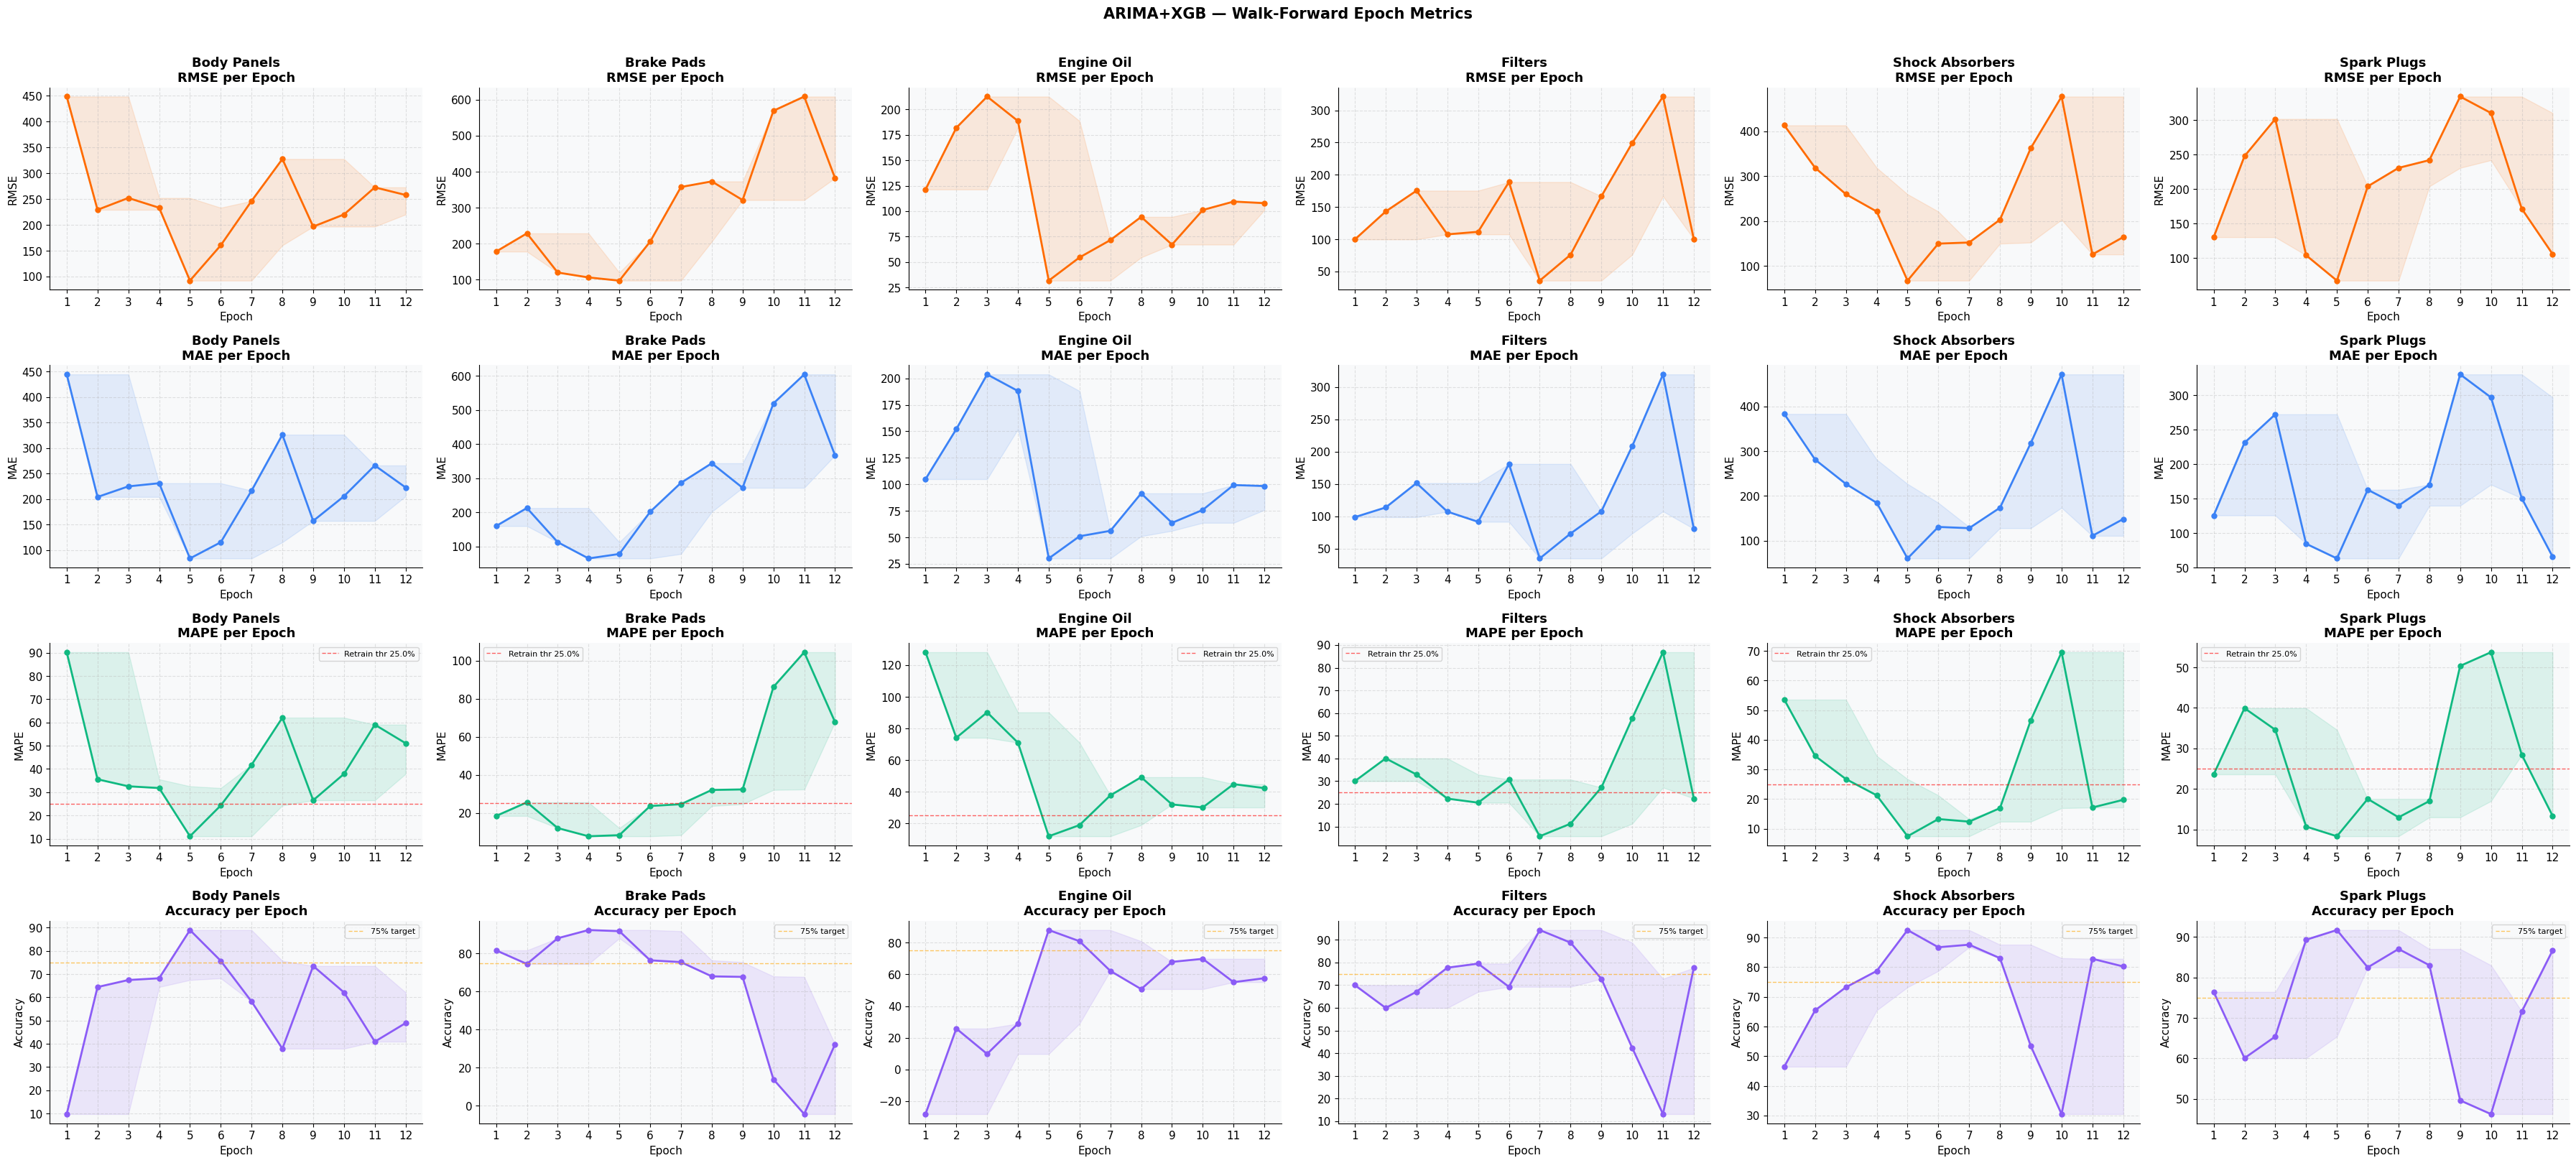

Saved: arima_epoch_metrics.png


In [6]:
n_prods = len(epoch_results)
fig, axes = plt.subplots(4, n_prods, figsize=(6*n_prods, 16))
if n_prods == 1: axes = axes.reshape(4,1)
metrics_to_plot = ['RMSE','MAE','MAPE','Accuracy']
colors_m = [ORANGE, BLUE, GREEN, PURPLE]

for col, (prod, records) in enumerate(epoch_results.items()):
    ep_df = pd.DataFrame(records)
    for row, (metric, color) in enumerate(zip(metrics_to_plot, colors_m)):
        ax = axes[row, col]
        ax.plot(ep_df['epoch'], ep_df[metric], color=color,
                linewidth=2, marker='o', markersize=5)
        ax.fill_between(ep_df['epoch'],
                        ep_df[metric].rolling(3,min_periods=1).min(),
                        ep_df[metric].rolling(3,min_periods=1).max(),
                        alpha=0.12, color=color)
        if metric == 'MAPE':
            ax.axhline(POOR_MAPE_THR, color='red', linestyle='--',
                       linewidth=1, alpha=0.6, label=f'Retrain thr {POOR_MAPE_THR}%')
            ax.legend(fontsize=8)
        if metric == 'Accuracy':
            ax.axhline(75, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='75% target')
            ax.legend(fontsize=8)
        ax.set_xlabel('Epoch'); ax.set_ylabel(metric)
        ax.set_title(f'{prod}\n{metric} per Epoch')
        ax.set_xticks(ep_df['epoch'])

plt.suptitle('ARIMA+XGB — Walk-Forward Epoch Metrics',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_epoch_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: arima_epoch_metrics.png')

In [7]:
# ── Epoch summary table ───────────────────────────────────────────────────────
print(f'\n{"═"*74}')
print('  ARIMA+XGB Epoch Summary — Mean ± Std across all epochs')
print(f'{"─"*74}')
print(f'  {"Product":<28} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Acc%":>10}')
print(f'{"─"*74}')
for prod, records in epoch_results.items():
    ep_df = pd.DataFrame(records)
    for metric in ['RMSE','MAE','MAPE','Accuracy']:
        pass  # just display
    r = ep_df
    print(f'  {prod:<28} '
          f'{r["RMSE"].mean():>6.2f}±{r["RMSE"].std():>4.2f}  '
          f'{r["MAE"].mean():>6.2f}±{r["MAE"].std():>4.2f}  '
          f'{r["MAPE"].mean():>6.1f}±{r["MAPE"].std():>4.1f}  '
          f'{r["Accuracy"].mean():>6.1f}±{r["Accuracy"].std():>4.1f}')
print(f'{"═"*74}')


══════════════════════════════════════════════════════════════════════════
  ARIMA+XGB Epoch Summary — Mean ± Std across all epochs
──────────────────────────────────────────────────────────────────────────
  Product                            RMSE        MAE      MAPE%       Acc%
──────────────────────────────────────────────────────────────────────────
  Body Panels                  244.72±86.86  224.72±94.38    42.0±21.0    58.0±21.0
  Brake Pads                   295.64±171.44  268.40±168.62    36.9±31.7    63.1±31.7
  Engine Oil                   111.85±56.15  101.24±54.29    52.6±33.1    47.4±33.1
  Filters                      147.93±78.85  130.57±75.94    32.3±21.7    67.7±21.7
  Shock Absorbers              243.22±125.69  218.20±122.63    28.3±19.1    71.7±19.1
  Spark Plugs                  204.16±88.71  174.45±89.74    25.9±15.6    74.1±15.6
══════════════════════════════════════════════════════════════════════════


## 7. Final Model Training (Full Dataset → Pickle)

In [8]:
final_models = {}  # product -> all trained artefacts
final_metrics = []

print(f'Training final models (test holdout = last {FINAL_TEST_SIZE} months)...\n')

for prod in arima_products:
    series = get_series(prod)
    n      = len(series)

    train_s = pd.Series(
        series.values[:-FINAL_TEST_SIZE].astype(float),
        index=pd.PeriodIndex(series.index[:-FINAL_TEST_SIZE], freq='M')
    )
    test_actual = series.values[-FINAL_TEST_SIZE:].astype(float)

    t0     = time.perf_counter()
    result = train_arima_xgb(train_s, FINAL_TEST_SIZE)
    elapsed = time.perf_counter() - t0

    met = compute_metrics(test_actual, result['forecast'])

    # ── Pickle bundle ──────────────────────────────────────────────────────────
    bundle = {
        'product':      prod,
        'algorithm':    'ARIMA_XGB',
        'arima_order':  result['best_order'],
        'arima_model':  result['arima_model'],   # statsmodels fitted ARIMA
        'xgb_model':    result['xgb_model'],     # xgb.XGBRegressor
        'scaler':       result['scaler'],         # StandardScaler
        'lag_features': LAG_FEATURES,
        'rolling_windows': ROLLING_WINDOWS,
        'ci_hw':        result['ci_hw'],
        'residuals':    result['residuals'],
        'arima_fitted': result['arima_fitted'],
        'train_index':  [str(p) for p in train_s.index],
        'train_values': train_s.values.tolist(),
        'metrics':      met,
        'xgb_params':   XGB_PARAMS,
        'trained_at':   pd.Timestamp.now().isoformat(),
        'n_train':      len(train_s),
        'horizon':      FINAL_TEST_SIZE,
        'ci_alpha':     CI_ALPHA,
    }

    pkl_path = PICKLE_DIR / f'arima_xgb_{prod.lower().replace(" ","_")}.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    final_models[prod] = {**bundle, 'forecast': result['forecast'],
                           'test_actual': test_actual, 'series': series}
    final_metrics.append({'Product': prod, **met})

    print(f'  ✅  {prod:<28}  MAPE={met["MAPE"]:>5.1f}%  '
          f'RMSE={met["RMSE"]:>7.2f}  saved → {pkl_path.name}  ({elapsed:.1f}s)')

metrics_df = pd.DataFrame(final_metrics)
print(f'\nAll models pickled to: {PICKLE_DIR.resolve()}')

Training final models (test holdout = last 6 months)...

  ✅  Body Panels                   MAPE= 19.8%  RMSE= 209.43  saved → arima_xgb_body_panels.pkl  (1.8s)


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅  Brake Pads                    MAPE= 14.7%  RMSE= 142.64  saved → arima_xgb_brake_pads.pkl  (1.6s)
  ✅  Engine Oil                    MAPE= 40.4%  RMSE= 167.93  saved → arima_xgb_engine_oil.pkl  (1.4s)
  ✅  Filters                       MAPE= 53.4%  RMSE= 260.82  saved → arima_xgb_filters.pkl  (1.4s)
  ✅  Shock Absorbers               MAPE= 43.0%  RMSE= 433.27  saved → arima_xgb_shock_absorbers.pkl  (1.3s)


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅  Spark Plugs                   MAPE= 17.8%  RMSE= 228.00  saved → arima_xgb_spark_plugs.pkl  (1.7s)

All models pickled to: C:\Users\Joem Inciong\automotive-spare-parts-dss-thesis\arima_xgb_models


## 8. Final Model Performance Metrics

In [9]:
print('╔' + '═'*68 + '╗')
print('║  ARIMA+XGB — Final Hold-Out Performance (last 6 months)          ║')
print('╠' + '═'*68 + '╣')
print(f'║  {"Product":<28} {"MSE":>10} {"RMSE":>8} {"MAE":>8} {"MAPE%":>7} {"Acc%":>7} ║')
print('╟' + '─'*68 + '╢')
for _, row in metrics_df.iterrows():
    flag = ' ⚠' if row['MAPE'] >= POOR_MAPE_THR else '  '
    print(f'║  {row["Product"]:<28} {row["MSE"]:>10.2f} {row["RMSE"]:>8.2f} '
          f'{row["MAE"]:>8.2f} {row["MAPE"]:>6.1f}% {row["Accuracy"]:>6.1f}%{flag} ║')
print('╟' + '─'*68 + '╢')
print(f'║  {"AVERAGE":<28} {metrics_df["MSE"].mean():>10.2f} {metrics_df["RMSE"].mean():>8.2f} '
      f'{metrics_df["MAE"].mean():>8.2f} {metrics_df["MAPE"].mean():>6.1f}% '
      f'{metrics_df["Accuracy"].mean():>6.1f}%   ║')
print('╚' + '═'*68 + '╝')
print('  ⚠ = MAPE above retrain threshold')

╔════════════════════════════════════════════════════════════════════╗
║  ARIMA+XGB — Final Hold-Out Performance (last 6 months)          ║
╠════════════════════════════════════════════════════════════════════╣
║  Product                             MSE     RMSE      MAE   MAPE%    Acc% ║
╟────────────────────────────────────────────────────────────────────╢
║  Body Panels                    43860.99   209.43   161.52   19.8%   80.2%   ║
║  Brake Pads                     20347.33   142.64   137.51   14.7%   85.3%   ║
║  Engine Oil                     28200.66   167.93   133.63   40.4%   59.6% ⚠ ║
║  Filters                        68028.61   260.82   254.18   53.4%   46.6% ⚠ ║
║  Shock Absorbers               187720.27   433.27   375.71   43.0%   57.0% ⚠ ║
║  Spark Plugs                    51982.66   228.00   173.60   17.8%   82.2%   ║
╟────────────────────────────────────────────────────────────────────╢
║  AVERAGE                        66690.09   240.35   206.03   31.5%   68.5%   ║
╚

## 9. Forecast vs Actual — Final Model

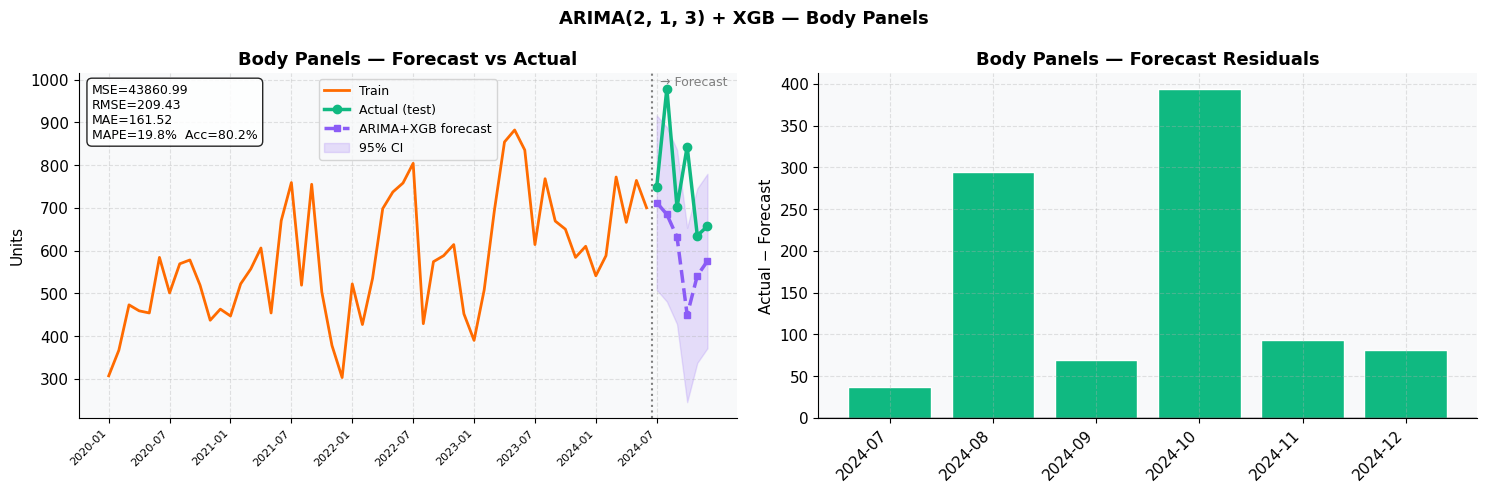

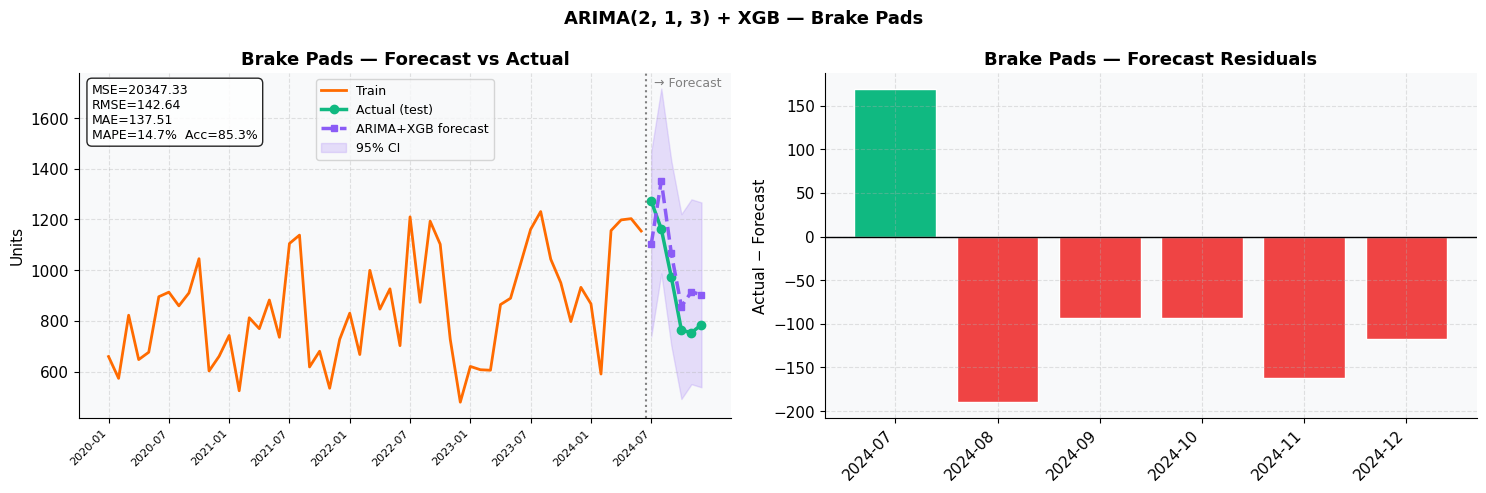

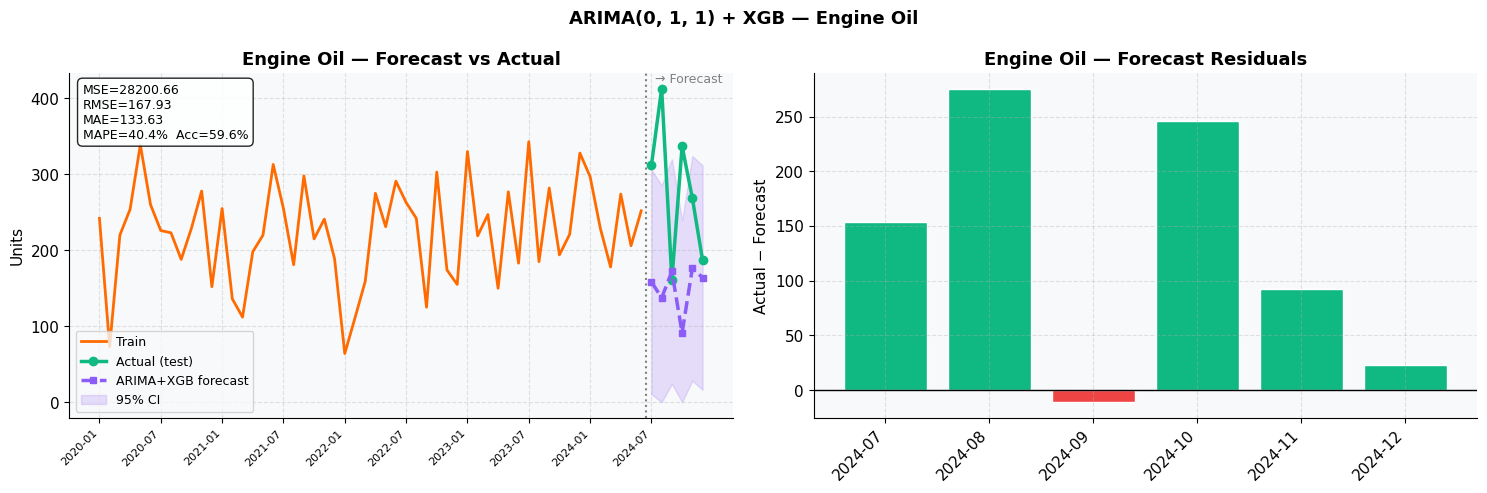

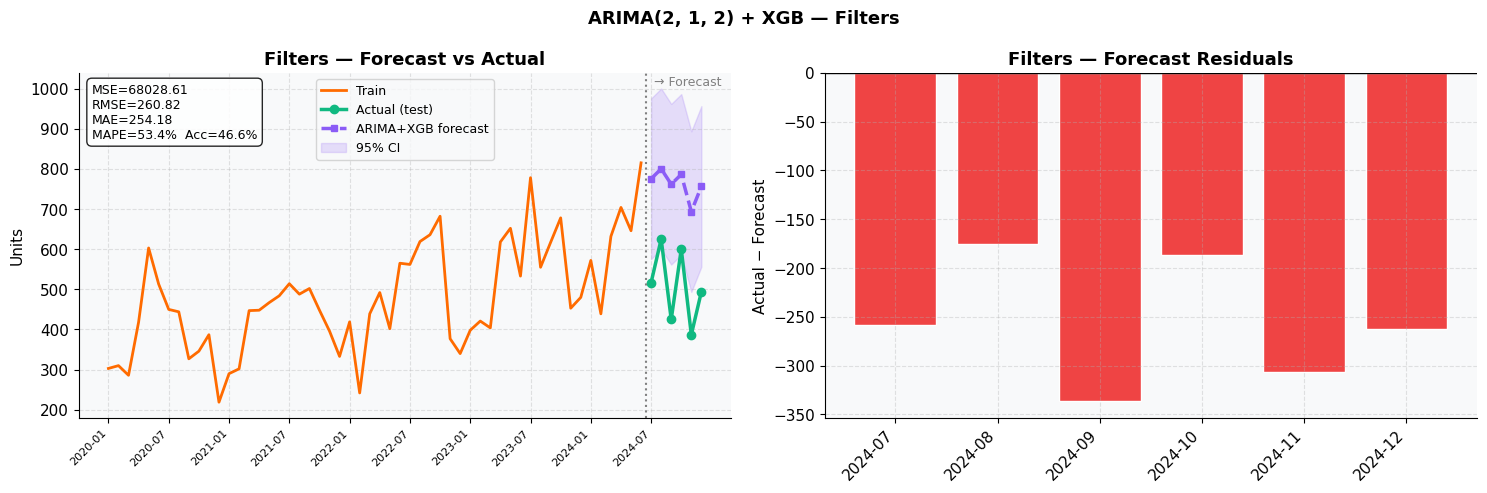

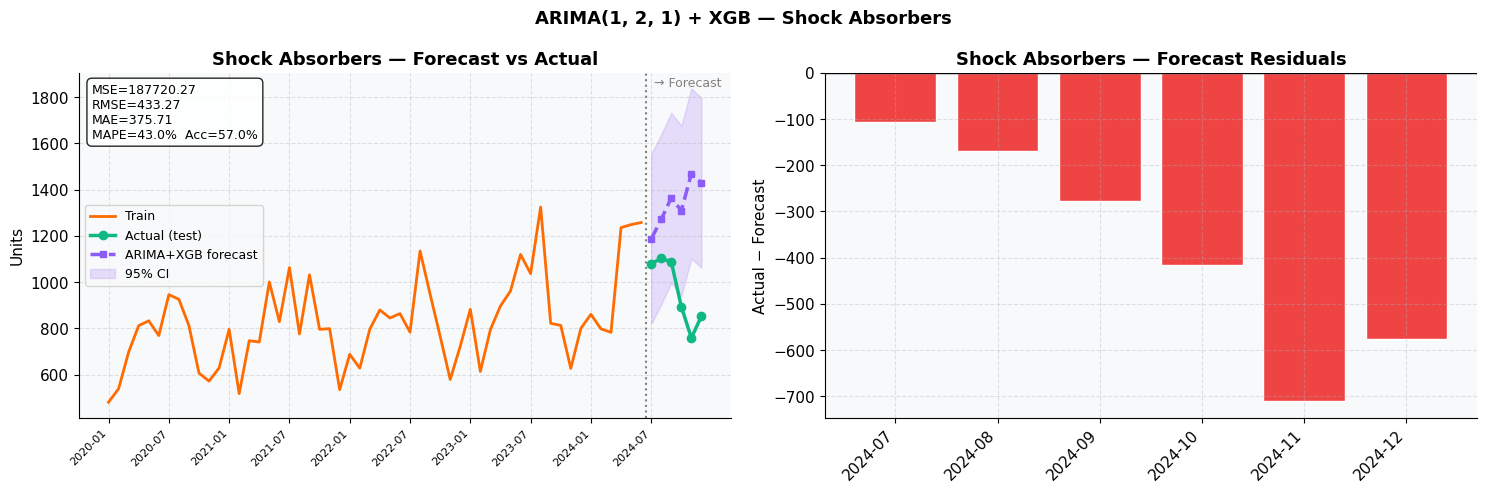

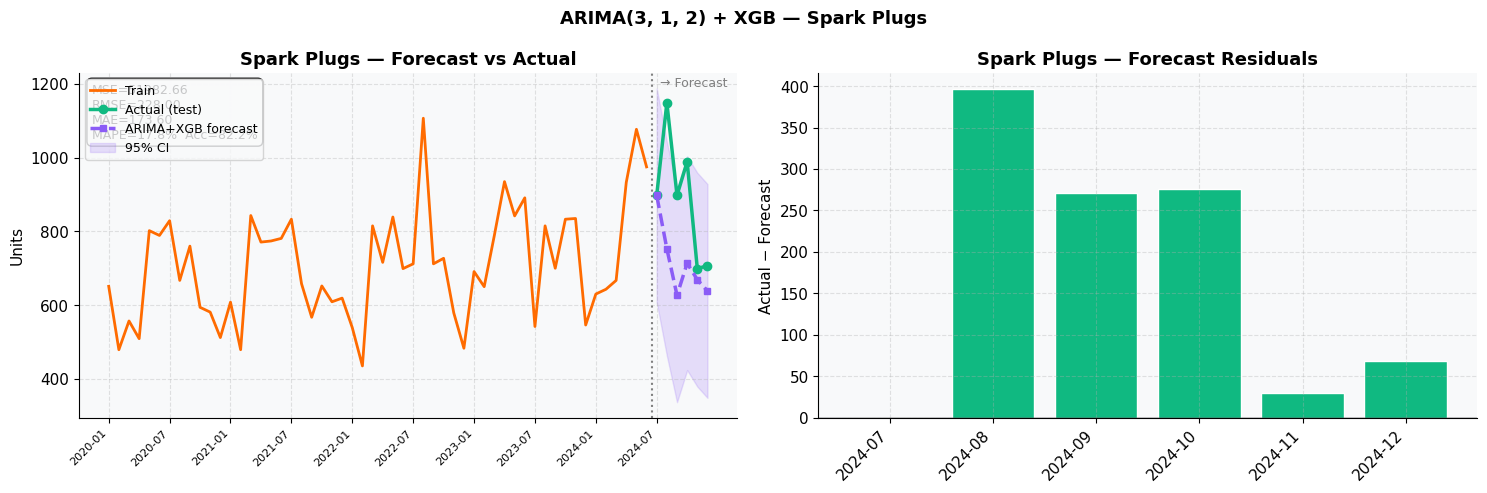

In [10]:
for prod, m in final_models.items():
    fc      = m['forecast']
    actual  = m['test_actual']
    series  = m['series']
    n_train = m['n_train']
    ci      = m['ci_hw']

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Left: full history + forecast
    ax = axes[0]
    train_vals = series.values[:n_train]
    x_train    = range(n_train)
    x_test     = range(n_train, n_train+FINAL_TEST_SIZE)
    ax.plot(x_train, train_vals, color=ORANGE, lw=2, label='Train')
    ax.plot(x_test,  actual,     color=GREEN,  lw=2.5, marker='o', ms=6, label='Actual (test)')
    ax.plot(x_test,  fc,         color=PURPLE, lw=2.5, ls='--', marker='s', ms=5, label='ARIMA+XGB forecast')
    ax.fill_between(x_test, np.maximum(0,fc-ci), fc+ci, alpha=0.18, color=PURPLE, label='95% CI')
    ax.axvline(n_train-0.5, color='gray', ls=':', lw=1.5)
    ax.text(n_train+0.3, ax.get_ylim()[1]*0.97, '→ Forecast', fontsize=9, color='gray')
    met = compute_metrics(actual, fc)
    ax.text(0.02, 0.97,
            f'MSE={met["MSE"]:.2f}\nRMSE={met["RMSE"]:.2f}\nMAE={met["MAE"]:.2f}\nMAPE={met["MAPE"]:.1f}%  Acc={met["Accuracy"]:.1f}%',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
    ax.set_title(f'{prod} — Forecast vs Actual'); ax.set_ylabel('Units'); ax.legend(fontsize=9)
    mn = len(series); step = max(1, mn//10)
    ax.set_xticks(list(range(0,mn,step)))
    ax.set_xticklabels([str(series.index[i]) for i in range(0,mn,step)], rotation=45, ha='right', fontsize=8)

    # Right: per-period error
    ax2   = axes[1]
    err   = actual - fc
    clrs  = [GREEN if e>=0 else '#ef4444' for e in err]
    xlbls = [str(p) for p in series.index[-FINAL_TEST_SIZE:]]
    ax2.bar(range(FINAL_TEST_SIZE), err, color=clrs, edgecolor='white')
    ax2.axhline(0, color='black', lw=1)
    ax2.set_xticks(range(FINAL_TEST_SIZE))
    ax2.set_xticklabels(xlbls, rotation=45, ha='right')
    ax2.set_title(f'{prod} — Forecast Residuals'); ax2.set_ylabel('Actual − Forecast')

    plt.suptitle(f'ARIMA{m["arima_order"]} + XGB — {prod}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    slug = prod.lower().replace(' ','_')
    plt.savefig(f'arima_final_forecast_{slug}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 10. Load from Pickle & Run Inference

In [11]:
# ── Demonstrate reloading a saved model ──────────────────────────────────────
# Pick the first product as example
example_prod  = arima_products[0]
example_pkl   = PICKLE_DIR / f'arima_xgb_{example_prod.lower().replace(" ","_")}.pkl'

with open(example_pkl, 'rb') as f:
    loaded = pickle.load(f)

print(f'Loaded model for: {loaded["product"]}')
print(f'  Algorithm    : {loaded["algorithm"]}')
print(f'  ARIMA order  : {loaded["arima_order"]}')
print(f'  Trained at   : {loaded["trained_at"]}')
print(f'  Train months : {loaded["n_train"]}')
print(f'  Saved metrics: MSE={loaded["metrics"]["MSE"]}  RMSE={loaded["metrics"]["RMSE"]}  '
      f'MAE={loaded["metrics"]["MAE"]}  MAPE={loaded["metrics"]["MAPE"]}%')

# ── Run new inference for the next 6 months ──────────────────────────────────
arima_mod  = loaded['arima_model']
xgb_mod    = loaded['xgb_model']
scaler     = loaded['scaler']
residuals  = np.array(loaded['residuals'])
ci_hw      = loaded['ci_hw']
NEW_HORIZON = 6

# Re-forecast from the fitted ARIMA (append to existing fit)
arima_new_fc = arima_mod.get_forecast(steps=NEW_HORIZON).predicted_mean.values

xgb_corr = []
window   = list(residuals)
for _ in range(NEW_HORIZON):
    feat = extract_feat(window)
    c    = float(xgb_mod.predict(scaler.transform([feat]))[0])
    xgb_corr.append(c); window.append(c)

new_fc = np.maximum(0, arima_new_fc + np.array(xgb_corr))
last_period = pd.Period(loaded['train_index'][-1], freq='M')
future = [str(last_period + i) for i in range(1, NEW_HORIZON+1)]

print(f'\n📅  Inference — next {NEW_HORIZON} months:')
print(f'  {"Period":<12} {"Forecast":>10} {"Lower95":>10} {"Upper95":>10}')
for p, v in zip(future, new_fc):
    lo = max(0, v-ci_hw); hi = v+ci_hw
    print(f'  {p:<12} {v:>10.1f} {lo:>10.1f} {hi:>10.1f}')

Loaded model for: Body Panels
  Algorithm    : ARIMA_XGB
  ARIMA order  : (2, 1, 3)
  Trained at   : 2026-03-26T01:16:58.842202
  Train months : 54
  Saved metrics: MSE=43860.9935  RMSE=209.4302  MAE=161.5237  MAPE=19.78%

📅  Inference — next 6 months:
  Period         Forecast    Lower95    Upper95
  2024-07           712.1      508.1      916.1
  2024-08           684.6      480.7      888.6
  2024-09           631.9      427.9      835.9
  2024-10           449.3      245.4      653.3
  2024-11           541.3      337.3      745.2
  2024-12           575.6      371.7      779.6


## 11. Pickle Contents Summary

In [12]:
pkl_files = sorted(PICKLE_DIR.glob('*.pkl'))
print(f'Saved pickle files in {PICKLE_DIR}/')
print(f'{"─"*55}')
total_bytes = 0
for p in pkl_files:
    size = p.stat().st_size
    total_bytes += size
    with open(p,'rb') as f:
        b = pickle.load(f)
    print(f'  {p.name:<45} {size/1024:>7.1f} KB')
    print(f'    ARIMA order: {b["arima_order"]}  '
          f'MAPE: {b["metrics"]["MAPE"]}%  '
          f'Acc: {b["metrics"]["Accuracy"]}%')
print(f'{"─"*55}')
print(f'  Total: {total_bytes/1024:.1f} KB  ({len(pkl_files)} files)')
print(f'\nTo reload any model:')
print("  import pickle")
print("  with open('arima_xgb_models/arima_xgb_<product>.pkl','rb') as f:")
print("      bundle = pickle.load(f)")
print("  arima_model = bundle['arima_model']")
print("  xgb_model   = bundle['xgb_model']")
print("  scaler      = bundle['scaler']")

Saved pickle files in arima_xgb_models/
───────────────────────────────────────────────────────
  arima_xgb_body_panels.pkl                       571.8 KB
    ARIMA order: (2, 1, 3)  MAPE: 19.78%  Acc: 80.22%
  arima_xgb_brake_pads.pkl                        585.6 KB
    ARIMA order: (2, 1, 3)  MAPE: 14.65%  Acc: 85.35%
  arima_xgb_engine_oil.pkl                        411.4 KB
    ARIMA order: (0, 1, 1)  MAPE: 40.42%  Acc: 59.58%
  arima_xgb_filters.pkl                           492.8 KB
    ARIMA order: (2, 1, 2)  MAPE: 53.42%  Acc: 46.58%
  arima_xgb_shock_absorbers.pkl                   488.8 KB
    ARIMA order: (1, 2, 1)  MAPE: 43.04%  Acc: 56.96%
  arima_xgb_spark_plugs.pkl                       484.7 KB
    ARIMA order: (3, 1, 2)  MAPE: 17.76%  Acc: 82.24%
───────────────────────────────────────────────────────
  Total: 3035.1 KB  (6 files)

To reload any model:
  import pickle
  with open('arima_xgb_models/arima_xgb_<product>.pkl','rb') as f:
      bundle = pickle.load(f)
  ari